In [1]:
from tqdm import tqdm
from multiprocess import Pool
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from distribution_test import *
import cmcrameri.cm as cmc
import os

In [2]:
params={     
    'axes.labelsize'  : '14',   
    'axes.titlesize'  : '14',  
    'xtick.labelsize' :'14',
    'ytick.labelsize' :'14',    
    'lines.linewidth' : '2' ,   
    'legend.fontsize' : '12', 
    'figure.figsize'   : '12, 7'    
}
plt.rcParams.update(params)

In [3]:

def scatter_to_contour(x_in,y_in,z_in):
    # 1D scattered data
    x = np.asarray(x_in)
    y = np.asarray(y_in)
    z = np.asarray(z_in)

    # make regular grid
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    Xi, Yi = np.meshgrid(xi, yi)

    # interpolate scattered data onto grid
    Zi = griddata((x, y), z, (Xi, Yi), method="linear")
    return Xi, Yi, Zi

In [4]:
def get_Palmer_plane_skew(z_lcl=1400,mprofile="cos",skew_type = "left", read_from_file=False):
    
    fname = f"Data/LCL_ext_{z_lcl}m_mprof-{mprofile}_skew-{skew_type}.csv"

    if os.path.exists(fname) & read_from_file:
       df = pd.read_csv(fname)
       return df

    # 1. Create (RH, P) pairs

    ## Use sequences
    #RH_values = np.linspace(0.01, 0.99, 50)
    #P_values = np.linspace(0, 20, 30)

    RH_values = np.linspace(0.02, 0.98, 25)
    P_values = np.linspace(0, 30, 31)


    param_pairs = [(RH, P) for RH in RH_values for P in P_values]

    # 2. Define worker function
    def worker(args):
        RH, P = args
        CAPE_u, CAPE_ext, CAPE_dist, dh, sat_def,dz,ent_b = spectral_plume_skew(
            model_type="precip", RH=RH, P=P, z_lcl=z_lcl,mprofile=mprofile,
            get_plane=True, plotting=False, save_data=False,skew_type = skew_type
        )
        return CAPE_u, CAPE_ext, CAPE_dist, dh, sat_def, P, RH,dz,ent_b

    # 3. Run in parallel
    num_cpus = 4
    with Pool(processes=num_cpus) as pool:
        results = list(tqdm(pool.imap(worker, param_pairs), total=len(param_pairs)))


    # 4. Unpack results
    CAPEu_list, CAPEext_list, CAPEdist_list, dh_list, sat_def_list, P_list,RH_list,dz_list,ent_b_list = zip(*results)
    CAPEu_list = list(CAPEu_list)
    CAPEext_list = list(CAPEext_list)
    CAPEdist_list = list(CAPEdist_list)
    dh_list = list(dh_list)
    sat_def_list = list(sat_def_list)
    P_list = list(P_list)
    RH_list = list(RH_list)
    dz_list = list(dz_list)
    ent_b_list = list(ent_b_list)

    # 5. Save to CSV
    df = pd.DataFrame({
        "CAPE_u":CAPEu_list,
        "CAPE_ext": CAPEext_list,
        "CAPE_dist": CAPEdist_list,
        "dh": dh_list,
        "sat_def": sat_def_list,
        "P": P_list,
        "RH": RH_list,
        "dz": dz_list,
        "ent_b":ent_b_list
                })
    df.to_csv(fname, index=False)

    return df

In [5]:
%%time

# Set the model parameters

z_lcl = 1400
mprofile = "cos"

df_normal = get_Palmer_plane_skew(z_lcl,mprofile,skew_type = "normal", read_from_file=False)

100%|██████████| 775/775 [01:37<00:00,  7.98it/s]

CPU times: user 404 ms, sys: 150 ms, total: 554 ms
Wall time: 1min 37s


In [6]:
%%time

df_left = get_Palmer_plane_skew(z_lcl,mprofile,skew_type = "left", read_from_file=False)
df_right = get_Palmer_plane_skew(z_lcl,mprofile,skew_type = "right", read_from_file=False)


  0%|          | 0/775 [00:00<?, ?it/s]

100%|██████████| 775/775 [01:37<00:00,  7.97it/s]

CPU times: user 844 ms, sys: 283 ms, total: 1.13 s
Wall time: 3min 14s


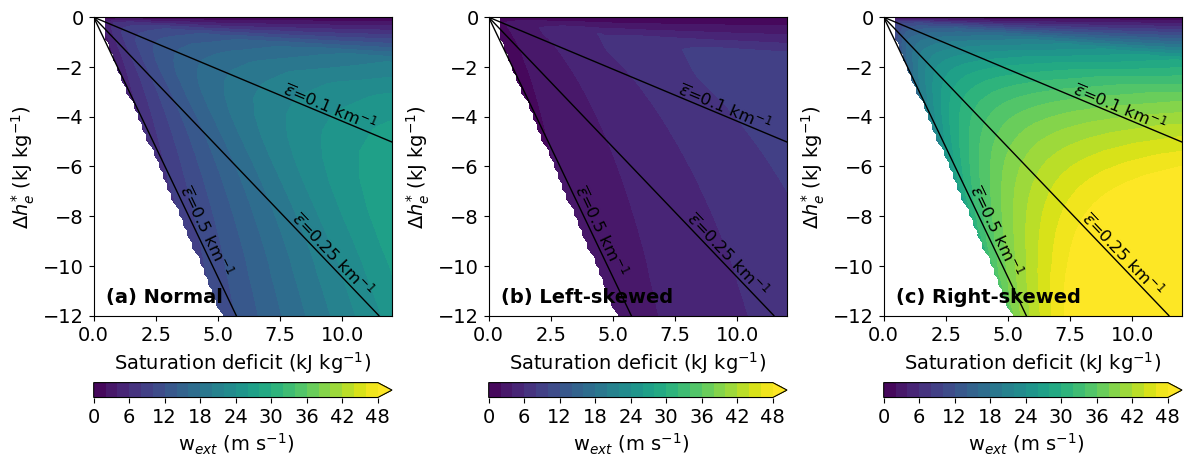

In [19]:

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(131)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_normal["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_normal["dh"])/1000
CAPEdist_list = np.array(df_normal["CAPE_dist"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_normal["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_normal["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi, levels=np.arange(0,50,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(a) Normal",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')

ax1 = fig.add_subplot(132)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_left["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_left["dh"])/1000
CAPEdist_list = np.array(df_left["CAPE_dist"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_left["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_left["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi, levels=np.arange(0,50,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(b) Left-skewed",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')

ax1 = fig.add_subplot(133)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_right["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_right["dh"])/1000
CAPEdist_list = np.array(df_right["CAPE_dist"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_right["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_right["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi, levels=np.arange(0,50,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(c) Right-skewed",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')
plt.tight_layout()

In [10]:
from scipy.stats import beta,norm 
def distribution_profile(nbins=50, skew="right"):
    x = np.linspace(0, 1, nbins)
    a = 4
    b = 16
    sigma = np.sqrt((a*b)/ ( (a+b)**2 * (a+b+1) ))
    
    if skew=="right":
        a = 4
        b = 16

        pdf = beta.pdf(x, a, b)
    elif skew == "normal":
        mu = 0.5
        sigma = sigma

        pdf = norm.pdf(x, loc=mu, scale=sigma)
    elif skew == "left":
        a = 16
        b = 4

        pdf = beta.pdf(x, a, b)
    else:
        raise ValueError(
                f"Input: {skew} is not a valid option. Please choose from 'right', 'normal', or 'left'."
            )
    return x, pdf 

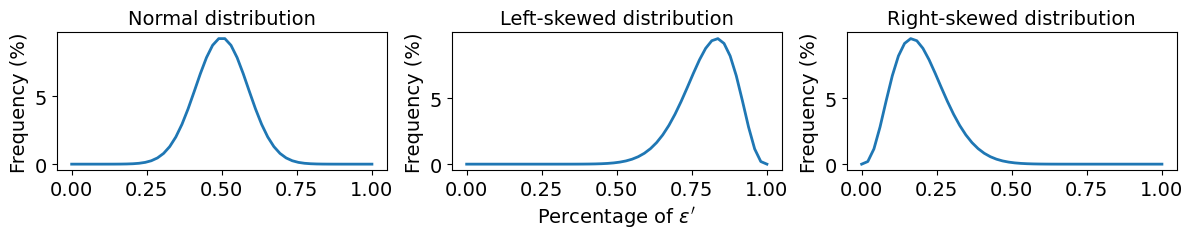

In [23]:

fig = plt.figure(figsize=(12,2.5))

ax1 = fig.add_subplot(131)
x,pdf = distribution_profile(nbins=50, skew="normal")
plt.plot(x,pdf/ pdf.sum()*100)
plt.title("Normal distribution")
plt.ylabel("Frequency (%)")

ax1 = fig.add_subplot(132)
x,pdf = distribution_profile(nbins=50, skew="left")
plt.plot(x,pdf/ pdf.sum()*100)
plt.title("Left-skewed distribution")
plt.ylabel("Frequency (%)")
plt.xlabel(r"Percentage of $\epsilon'$")

ax1 = fig.add_subplot(133)
x,pdf = distribution_profile(nbins=50, skew="right")
plt.plot(x,pdf/ pdf.sum()*100)
plt.title("Right-skewed distribution")
plt.ylabel("Frequency (%)")
plt.tight_layout()